# **PROBLEM 2: CHARACTER-LEVEL NAME GENERATION USING RNN VARIANTS**

In [1]:
# Installing dependencies
!pip install torch torchvision --quiet
!pip install matplotlib seaborn --quiet
print(" Dependencies ready.")

✅ Dependencies ready.


In [2]:
# Task-0 — Generate 1000 Indian names and save to TrainingNames.txt
# Names span Hindu, Muslim, Sikh, South Indian, Bengali, Punjabi traditions

import random

indian_names = [
    # North Indian Hindu - Male
    "Aarav", "Aditya", "Akash", "Amit", "Anand", "Arjun", "Aryan", "Ashish", "Ayush", "Bhavesh",
    "Chirag", "Deepak", "Dhruv", "Gaurav", "Harsh", "Hemant", "Hitesh", "Ishan", "Jai", "Karan",
    "Kartik", "Kunal", "Lakshay", "Manish", "Mohit", "Naman", "Nikhil", "Nilesh", "Nishant", "Om",
    "Pankaj", "Pranav", "Prateek", "Praveen", "Pulkit", "Rahul", "Raj", "Rajat", "Rakesh", "Ram",
    "Ritesh", "Rohan", "Rohit", "Sachin", "Sahil", "Saksham", "Saurabh", "Shivam", "Shubham", "Siddharth",
    "Sourabh", "Sumit", "Suraj", "Tarun", "Uday", "Vaibhav", "Vikas", "Vikram", "Vinay", "Vishal",
    "Yash", "Yogesh", "Aakash", "Abhay", "Abhinav", "Abhishek", "Ajay", "Ajit", "Akhil",
    "Alok", "Amar", "Amol", "Amrit", "Aniket", "Anil", "Anirudh", "Ankur",
    "Anshul", "Anup", "Anurag", "Arnav", "Arun", "Ashok", "Ashutosh", "Atharv", "Atul",
    "Avinash", "Bhuvan", "Chetan", "Daksh", "Darshan", "Dev", "Devesh", "Dinesh", "Divyansh",
    # North Indian Hindu - Female
    "Aisha", "Ananya", "Ankita", "Anushka", "Arpita", "Avni", "Deepika", "Disha", "Divya", "Garima",
    "Ishita", "Jyoti", "Kajal", "Kavita", "Komal", "Kritika", "Lakshmi", "Mansi", "Meera", "Megha",
    "Mona", "Neha", "Nidhi", "Nikita", "Nimisha", "Nisha", "Pallavi", "Payal", "Poorvi", "Pooja",
    "Prachi", "Pragya", "Priya", "Priyanshi", "Puja", "Purvi", "Radha", "Rakhi", "Rashmi", "Reena",
    "Riddhi", "Riya", "Ruhi", "Sakshi", "Sana", "Sandhya", "Sapna", "Shivani", "Shreya", "Shruti",
    "Simran", "Sneha", "Sonam", "Srishti", "Swati", "Tanvi", "Tanya", "Trisha", "Uma", "Urvashi",
    "Vanshika", "Varsha", "Vibha", "Vidhi", "Vijaya", "Vrinda", "Yamini", "Yukti", "Zara", "Zoya",
    # South Indian - Female
    "Aarthi", "Abarna", "Aditi", "Aishwarya", "Akshara", "Amala", "Amitha", "Amritha", "Anagha",
    "Anitha", "Anjali", "Archana", "Arundhati", "Bhavana", "Bhavya", "Brinda", "Chandra", "Chandrika", "Chithra",
    "Deepa", "Deepthi", "Dhanya", "Gayathri", "Geetha", "Girija", "Haritha", "Hema", "Indira",
    "Janaki", "Jayalakshmi", "Jayanthi", "Jyothika", "Kala", "Kalai", "Kamala", "Karthika", "Kaveri", "Kavitha",
    "Keerthana", "Kirthana", "Krithika", "Lalitha", "Lavanya", "Lekha", "Leela", "Madhavi", "Malathi", "Malini",
    "Meenakshi", "Menaka", "Mithra", "Mythili", "Nandita", "Nandhini", "Narmada", "Nithya",
    "Oviya", "Padma", "Padmavathi", "Padmini", "Pavithra", "Preethi", "Premalatha", "Priyadarshini",
    "Rajeshwari", "Ramya", "Ranjani", "Renuka", "Rohini", "Rukhmini", "Sadhana", "Saraswathi", "Saroja", "Savitha",
    "Selvi", "Shanthi", "Sharada", "Shobha", "Sivakami", "Sowmya", "Sridevi", "Srilakshmi",
    "Sudha", "Suganya", "Suhasini", "Sukanya", "Sulochana", "Sumathi", "Sunitha", "Supriya", "Surekha", "Susheela",
    "Tara", "Thenmozhi", "Vaishnavi", "Valarmathi", "Vasantha", "Vasanthi", "Veena", "Vennila",
    "Vijayalakshmi", "Vidhya", "Vinodhini", "Visalakshi", "Yashodha",
    # South Indian - Male
    "Adhithya", "Ajith", "Akilan", "Aravind", "Arulraj",
    "Ashwin", "Balaji", "Balachandran", "Balamurugan", "Chandrasekhar", "Dhanush", "Ezhilan", "Ganesh",
    "Gopal", "Gopinath", "Hariprasad", "Harish", "Hari", "Jagadish", "Jagan", "Jayakumar", "Jayaram",
    "Karthikeyan", "Karunakar", "Karunakaran", "Kathirvel", "Kesavan", "Kiran",
    "Krishnamurthy", "Krishnan", "Kumar", "Kumaresan", "Kumaravel", "Lakshmanan", "Logesh", "Madhan", "Madan", "Mahesh",
    "Manikandan", "Manoharan", "Marimuthu", "Mithun", "Mohan", "Murugan",
    "Nandakumar", "Narayanan", "Natarajan", "Naveenkumar", "Naveen", "Nithin", "Prabakaran", "Prabhu",
    "Prasanna", "Prasanth", "Prathap", "Premkumar", "Raghavan", "Rajasekaran", "Rajesh", "Rajkumar",
    "Ramalingam", "Ramesh", "Ramkumar", "Ranjith", "Ravi", "Ravichandran", "Ravikumar", "Sabarish", "Sanjay",
    "Saravanan", "Sathish", "Selvam", "Senthil", "Senthilkumar", "Shanmugam", "Shankar", "Shiva", "Silambarasan",
    "Sivakumar", "Sivaraj", "Soundarajan", "Subramanian", "Sudhakar", "Suresh", "Surya", "Udhayakumar",
    "Vignesh", "Vijay", "Vijayakumar", "Vikraman", "Vinoth", "Vishwanath", "Yuvaraj",
    # Punjabi / Sikh
    "Amandeep", "Amanjot", "Amanpreet", "Amarjit", "Amritpal", "Arshdeep", "Baldev", "Balwinder",
    "Daljeet", "Daljit", "Dalvinder", "Dilpreet", "Gagandeep", "Gurdeep", "Gurjeet",
    "Gurmeet", "Gurnam", "Gurpreet", "Gurwinder", "Hardeep", "Harjeet", "Harjinder", "Harjot", "Harmeet", "Harpreet",
    "Harvinder", "Harsimran", "Inderjit", "Jagjeet", "Jagmeet", "Jagtar", "Jaswinder", "Jatinder",
    "Karamjit", "Kuldeep", "Kulwinder", "Lakhwinder", "Mandeep", "Manjeet", "Manpreet",
    "Navdeep", "Navjot", "Navpreet", "Parminder", "Ranjit", "Ravinder", "Sarabjit", "Satinder", "Satnam",
    "Simarpreet", "Sukhpreet", "Surinder", "Tejinder",
    # Bengali
    "Abhirup", "Anirban", "Animesh", "Aniruddha", "Antara", "Anuradha", "Aparajita", "Aparna", "Arnab", "Arunava",
    "Atanu", "Avijit", "Bikash", "Biswarup", "Bratati", "Chandana", "Debashis", "Debashree", "Debjani",
    "Dipankar", "Durga", "Goutam", "Indranil", "Jayita", "Kaushik", "Koushani", "Madhurima", "Maitreyi",
    "Mainak", "Mandira", "Mitali", "Moumita", "Nilanjana", "Poulami", "Priyanka",
    "Rituparno", "Rupali", "Sabyasachi", "Saikat", "Samaresh", "Sangeeta",
    "Sanjukta", "Sayantani", "Sharmistha", "Shibani", "Shilpi", "Soumyadip", "Souvik", "Subhajit",
    "Subhashree", "Sudipto", "Susmita", "Sutapa", "Swagata", "Swapna", "Tithi", "Trishna", "Urmi",
    # Muslim names common in India
    "Abdullah", "Adnan", "Ahmad", "Ahsan", "Akbar", "Ali", "Altaf", "Arbaaz", "Arif",
    "Asad", "Atif", "Ayaan", "Azaan", "Azhar", "Danish", "Faisal", "Faiz", "Farhan",
    "Hamid", "Hamza", "Hasan", "Hassan", "Hussain", "Ibrahim", "Imran",
    "Irfan", "Junaid", "Kamran", "Khalid", "Luqman", "Mohsin", "Mustafa",
    "Nadeem", "Nasir", "Nauman", "Nawaz", "Omar", "Qasim", "Raza", "Rizwan", "Saad", "Saleem", "Salman",
    "Shahid", "Shakeel", "Shoaib", "Sohail", "Tariq", "Umar", "Usman", "Waseem", "Zafar", "Zahid",
    "Zain", "Zubair", "Aabida", "Afreen", "Aliya", "Asma", "Bushra", "Faiza", "Fatima",
    "Hina", "Huma", "Lubna", "Mariam", "Munira", "Naima", "Nasreen", "Nazia",
    "Parveen", "Rehana", "Rukhsar", "Saba", "Saima", "Salma", "Samreen", "Shirin",
    "Sumaira", "Tahira", "Yasmin", "Zainab",
]

base_names = list(set(indian_names))
print(f"Base unique names: {len(base_names)}")

# Augment to 1000 with common Indian name patterns
# Using real Indian name components, not random suffixes
male_components   = ["raj", "kumar", "dev", "pal", "nath", "das", "ram", "lal", "hari", "kant"]
female_components = ["lata", "devi", "bai", "mati", "prabha", "vati", "rani", "wati", "kala", "mala"]
prefixes = ["Sri", "Dev", "Raj", "Hari", "Uma", "Kala", "Mala", "Gita", "Lata", "Shri"]

augmented = list(base_names)
random.seed(42)

while len(augmented) < 1000:
    base = random.choice(base_names)
    choice = random.random()
    if choice < 0.33:
        candidate = base + random.choice(male_components)
    elif choice < 0.66:
        candidate = base + random.choice(female_components)
    else:
        candidate = random.choice(prefixes) + base
    candidate = candidate.capitalize()
    if candidate not in augmented:
        augmented.append(candidate)

final_names = augmented[:1000]
random.shuffle(final_names)

with open("TrainingNames.txt", "w") as f:
    for name in final_names:
        f.write(name + "\n")

print(f" Saved {len(final_names)} names to TrainingNames.txt")
print("Sample:", final_names[:10])

Base unique names: 556
✅ Saved 1000 names to TrainingNames.txt
Sample: ['Akbar', 'Umadhanush', 'Lakshmi', 'Murugankant', 'Rajasekaran', 'Huma', 'Kalaadnan', 'Umasivaraj', 'Dalvinder', 'Jagankant']


In [3]:
# Data Preprocessing — vocabulary and dataset
# All three models share this vocabulary and DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os, json, time

# Load names
with open("TrainingNames.txt", "r") as f:
    all_names = [line.strip() for line in f if line.strip()]

print(f"Total names: {len(all_names)}")
print(f"Avg length: {np.mean([len(n) for n in all_names]):.2f}")
print(f"Min/Max: {min(len(n) for n in all_names)} / {max(len(n) for n in all_names)}")

# Build character vocabulary
all_chars = sorted(set("".join(all_names)))
vocab     = ["<PAD>", "<SOS>", "<EOS>"] + all_chars
char2idx  = {ch: i for i, ch in enumerate(vocab)}
idx2char  = {i: ch for ch, i in char2idx.items()}

PAD_IDX   = char2idx["<PAD>"]
SOS_IDX   = char2idx["<SOS>"]
EOS_IDX   = char2idx["<EOS>"]
VOCAB_SIZE = len(vocab)

print(f"\nVocab size: {VOCAB_SIZE}")
print(f"Characters: {''.join(all_chars)}")

def encode_name(name):
    """Name string → [SOS, c1, c2, ..., cn, EOS]"""
    return [SOS_IDX] + [char2idx[c] for c in name] + [EOS_IDX]

def decode_indices(indices):
    """Index list → name string (stops at EOS)"""
    chars = []
    for idx in indices:
        if idx == EOS_IDX: break
        if idx not in (PAD_IDX, SOS_IDX):
            chars.append(idx2char[idx])
    return "".join(chars)

encoded_names = [encode_name(n) for n in all_names]
max_len = max(len(e) for e in encoded_names)
print(f"Max seq length (with SOS/EOS): {max_len}")

class NameDataset(Dataset):
    """
    Character-level name dataset.
    input  = [SOS, c1, c2, ..., cn]    (teacher-forcing input)
    target = [c1, c2, ..., cn, EOS]    (next-char prediction targets)
    Both padded to max_len.
    """
    def __init__(self, encoded_names, max_len, pad_idx):
        self.samples = []
        for seq in encoded_names:
            inp = seq[:-1]
            tgt = seq[1:]
            inp = inp + [pad_idx] * (max_len - len(inp))
            tgt = tgt + [pad_idx] * (max_len - len(tgt))
            self.samples.append((
                torch.tensor(inp, dtype=torch.long),
                torch.tensor(tgt, dtype=torch.long)
            ))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

dataset    = NameDataset(encoded_names, max_len, PAD_IDX)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

torch.save({
    "char2idx": char2idx, "idx2char": idx2char, "vocab": vocab,
    "vocab_size": VOCAB_SIZE, "pad_idx": PAD_IDX, "sos_idx": SOS_IDX,
    "eos_idx": EOS_IDX, "max_len": max_len, "all_names": all_names
}, "vocab.pt")

print(" Dataset ready. vocab.pt saved.")

Total names: 1000
Avg length: 8.26
Min/Max: 2 / 17

Vocab size: 53
Characters: ABCDEFGHIJKLMNOPQRSTUVWYZabcdefghijklmnopqrstuvwyz
Max seq length (with SOS/EOS): 19
✅ Dataset ready. vocab.pt saved.


In [4]:
# Model 1 — Vanilla RNN (from scratch, no nn.RNN)
#
# Architecture:
#   Embedding → Manual RNN cell (tanh) × num_layers → FC → logits
#   h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b)
#
# The manual RNN cell is implemented using nn.Linear weights
# to demonstrate understanding of the recurrent computation.

class VanillaRNN(nn.Module):
    """
    Vanilla RNN for character-level name generation.

    Manually implements the RNN recurrence:
        h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b_h)

    Hidden state is a list of tensors (one per layer), compatible
    with step-by-step autoregressive generation from the start.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.vocab_size  = vocab_size

        # Embedding: token index → dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Manual RNN weights per layer
        self.W_ih = nn.ModuleList()
        self.W_hh = nn.ModuleList()
        self.b_h  = nn.ParameterList()
        for layer in range(num_layers):
            in_dim = embed_dim if layer == 0 else hidden_size
            self.W_ih.append(nn.Linear(in_dim,     hidden_size, bias=False))
            self.W_hh.append(nn.Linear(hidden_size, hidden_size, bias=False))
            self.b_h.append(nn.Parameter(torch.zeros(hidden_size)))

        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        """
        x      : (batch, seq_len)
        hidden : list of (batch, hidden_size) tensors, one per layer, or None
        Returns: logits (batch, seq_len, vocab_size), hidden (list)
        """
        batch_size, seq_len = x.shape
        embed = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Initialise hidden states to zero if not provided
        if hidden is None:
            hidden = [torch.zeros(batch_size, self.hidden_size, device=x.device)
                      for _ in range(self.num_layers)]

        outputs = []
        for t in range(seq_len):
            x_t = embed[:, t, :]          # (batch, embed_dim)
            new_hidden = []
            for layer in range(self.num_layers):
                # Core RNN recurrence
                h_t = torch.tanh(
                    self.W_ih[layer](x_t) +
                    self.W_hh[layer](hidden[layer]) +
                    self.b_h[layer]
                )
                h_t = self.dropout(h_t)
                new_hidden.append(h_t)
                x_t = h_t              # output of this layer is input to next
            hidden = new_hidden
            outputs.append(hidden[-1].unsqueeze(1))

        all_out = torch.cat(outputs, dim=1)        # (batch, seq_len, hidden)
        logits  = self.fc_out(all_out)             # (batch, seq_len, vocab_size)
        return logits, hidden

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

rnn_model = VanillaRNN(VOCAB_SIZE, embed_dim=64, hidden_size=256, num_layers=2, dropout=0.3)
print(f"Model 1 — Vanilla RNN")
print(f"  embed_dim=64, hidden=256, layers=2, dropout=0.3")
print(f"  Trainable params: {rnn_model.count_parameters():,}")

Model 1 — Vanilla RNN
  embed_dim=64, hidden=256, layers=2, dropout=0.3
  Trainable params: 230,517


In [5]:
# Bidirectional LSTM

# Architecture:
#   Embedding → BiLSTM encoder on [SOS] only → project h,c →
#   Unidirectional LSTM decoder (teacher-forced) → FC → logits

class BidirectionalLSTM(nn.Module):
    """
    Bidirectional LSTM for character-level name generation.

    The BiLSTM encoder processes ONLY the SOS token to compute a rich
    initial hidden state for the unidirectional decoder. The decoder
    then generates characters autoregressively using teacher forcing
    during training — identical to generation mode.

    This design ensures COMPLETE consistency between training and generation:
    both always start with BiLSTM([SOS]) as the initial decoder state.

    Architecture:
      1. BiLSTM encoder: embeds [SOS] → bidirectional hidden states
                         → project 2*hidden → hidden (for h and c separately)
      2. Unidirectional LSTM decoder: generates sequence step by step
      3. FC output: hidden → vocab logits
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super(BidirectionalLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.vocab_size  = vocab_size

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout   = nn.Dropout(dropout)

        # BiLSTM encoder — only ever sees the SOS embedding (single token)
        # bidirectional=True means hidden size doubles: output is 2*hidden_size
        self.encoder = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        # Project bidirectional (fwd+bwd) hidden/cell → decoder size
        # Input: 2*hidden_size (fwd concat bwd), Output: hidden_size
        self.h_proj = nn.Linear(2 * hidden_size, hidden_size)
        self.c_proj = nn.Linear(2 * hidden_size, hidden_size)

        # Unidirectional LSTM decoder — autoregressive, one token at a time
        self.decoder = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def _get_initial_hidden(self, batch_size, device):
        """
        Compute initial decoder (h, c) by running BiLSTM on the SOS token.
        Called once at the START of every forward pass (training and generation).
        batch_size: number of sequences in current batch
        """
        # Create a batch of SOS tokens: (batch_size, 1)
        sos_tokens = torch.full(
            (batch_size, 1), SOS_IDX, dtype=torch.long, device=device
        )
        # Embed SOS: (batch_size, 1, embed_dim)
        sos_embed = self.dropout(self.embedding(sos_tokens))

        # Run through BiLSTM — only 1 timestep
        # h_enc: (2*num_layers, batch, hidden) — interleaved fwd/bwd
        _, (h_enc, c_enc) = self.encoder(sos_embed)

        # Separate forward and backward layers
        # Even indices: forward layers (0, 2, 4...)
        # Odd indices:  backward layers (1, 3, 5...)
        h_fwd = h_enc[0::2]   # (num_layers, batch, hidden)
        h_bwd = h_enc[1::2]
        c_fwd = c_enc[0::2]
        c_bwd = c_enc[1::2]

        # Concatenate fwd+bwd: (num_layers, batch, 2*hidden)
        h_cat = torch.cat([h_fwd, h_bwd], dim=-1)
        c_cat = torch.cat([c_fwd, c_bwd], dim=-1)

        # Project each layer independently to decoder hidden size
        h0 = torch.stack([self.h_proj(h_cat[l]) for l in range(self.num_layers)])
        c0 = torch.stack([self.c_proj(c_cat[l]) for l in range(self.num_layers)])
        return h0, c0

    def forward(self, x, hidden=None):
        """
        x      : (batch, seq_len) — input token indices
        hidden : (h, c) decoder state, or None for first call

        TRAINING (hidden=None, x = full sequence with SOS prefix):
          Computes initial (h,c) from BiLSTM([SOS]) for the whole batch,
          then runs full sequence through unidirectional decoder.

        GENERATION (step-by-step):
          First call: hidden=None, x=[[SOS]] → gets h0,c0, decodes 1 step
          Next calls: hidden=(h,c) from previous step, x=[[last_token]]
          The initial hidden is IDENTICAL to training (BiLSTM on SOS).

        Returns: logits (batch, seq_len, vocab_size), (h, c)
        """
        batch_size = x.shape[0]
        device     = x.device

        if hidden is None:
            # Compute fresh initial hidden state from BiLSTM encoder on SOS
            # This is ALWAYS done at the start — training or generation
            h0, c0 = self._get_initial_hidden(batch_size, device)
            hidden = (h0, c0)

        # Decode: embed x and run through unidirectional LSTM
        embed   = self.dropout(self.embedding(x))       # (batch, seq_len, embed_dim)
        dec_out, hidden = self.decoder(embed, hidden)   # (batch, seq_len, hidden)
        dec_out = self.dropout(dec_out)
        logits  = self.fc_out(dec_out)                  # (batch, seq_len, vocab_size)
        return logits, hidden

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Reinstantiate with fresh weights
blstm_model = BidirectionalLSTM(
    VOCAB_SIZE, embed_dim=64, hidden_size=256, num_layers=2, dropout=0.3
)
print(f"Model 2 — Bidirectional LSTM (FIXED)")
print(f"  BiLSTM encoder: always encodes [SOS] only")
print(f"  Unidirectional decoder: learns character transitions")
print(f"  embed_dim=64, hidden=256 (BiLSTM=512 internally), layers=2")
print(f"  Trainable params: {blstm_model.count_parameters():,}")

# Verify: training and generation start with IDENTICAL encoder input
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
blstm_model = blstm_model.to(device)
h0, c0 = blstm_model._get_initial_hidden(batch_size=1, device=device)
print(f"\nEncoder hidden state shape: {h0.shape}")  # (num_layers, 1, hidden)
print(" Encoder correctly produces fixed initial state from SOS token")
blstm_model = blstm_model.cpu()

Model 2 — Bidirectional LSTM (FIXED)
  BiLSTM encoder: always encodes [SOS] only
  Unidirectional decoder: learns character transitions
  embed_dim=64, hidden=256 (BiLSTM=512 internally), layers=2
  Trainable params: 3,372,149

Encoder hidden state shape: torch.Size([2, 1, 256])
✅ Encoder correctly produces fixed initial state from SOS token


In [6]:
# Model 3 — RNN with Basic Bahdanau Attention Mechanism
#
# Architecture:
#   Embedding → RNN (step-by-step) → Bahdanau Attention over past GRU outputs
#             → gated blend(h_t, context) → FC → logits
#
# Attention formula:
#   score(h_t, h_i) = v^T * tanh(W_q * h_t + W_k * h_i)
#   weights = softmax(scores)
#   context = Σ weights_i * h_i
#
# KEY DESIGN DECISION for autoregressive consistency:
#   Attention attends over the GRU's OWN past outputs [h_0..h_{t-1}].
#   Training: keys built from earlier timesteps in same batch.
#   Generation: keys are a growing buffer of past outputs passed explicitly.
#   → IDENTICAL computation in both modes.

class BahdanauAttention(nn.Module):
    """
    Basic Bahdanau (additive) attention.
    score(query, key_i) = v^T * tanh(W_q * query + W_k * key_i)
    """
    def __init__(self, hidden_size, attention_dim):
        super(BahdanauAttention, self).__init__()
        self.W_q = nn.Linear(hidden_size, attention_dim, bias=False)
        self.W_k = nn.Linear(hidden_size, attention_dim, bias=False)
        self.v   = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, query, keys):
        """
        query : (batch, hidden)    current GRU output
        keys  : (batch, t, hidden) past GRU outputs
        Returns context (batch, hidden), weights (batch, t)
        """
        q       = self.W_q(query).unsqueeze(1)                  # (batch, 1, attn_dim)
        k       = self.W_k(keys)                                # (batch, t, attn_dim)
        scores  = self.v(torch.tanh(q + k)).squeeze(-1)         # (batch, t)
        weights = F.softmax(scores, dim=-1)                     # (batch, t)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)  # (batch, hidden)
        return context, weights


class RNNWithAttention(nn.Module):
    """
    RNN with Basic Bahdanau Attention for character-level name generation.

    At each timestep t:
      1. RNN processes embedding of current token → h_t
      2. Attention over past GRU outputs [h_0..h_{t-1}] → context c_t
      3. Gate blends h_t and c_t → output representation o_t
      4. FC(o_t) → logits over vocabulary

    At t=0: no past outputs exist, so output = FC(dropout(h_0)) directly.

    past_outputs parameter:
      - Training: None (keys computed internally from current batch)
      - Generation: growing tensor of past h's, passed from outside
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers,
                 attention_dim=128, dropout=0.3):
        super(RNNWithAttention, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.vocab_size  = vocab_size

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout   = nn.Dropout(dropout)

        # GRU: gated recurrence — no vanishing gradient, standard for attention
        self.gru = nn.GRU(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Bahdanau attention module
        self.attention = BahdanauAttention(hidden_size, attention_dim)

        # Gating: learned blend of current hidden + attended context
        self.gate   = nn.Linear(2 * hidden_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None, past_outputs=None):
        """
        x            : (batch, seq_len)
        hidden       : GRU hidden (num_layers, batch, hidden) or None
        past_outputs : (batch, T_past, hidden) for generation mode, else None
        Returns: logits (batch, seq_len, vocab), hidden, gru_outputs
        """
        embed = self.dropout(self.embedding(x))
        gru_out, hidden = self.gru(embed, hidden)  # (batch, seq_len, hidden)

        all_logits = []
        for t in range(x.shape[1]):
            h_t = gru_out[:, t, :]                 # (batch, hidden)

            if past_outputs is not None:
                # Generation mode: use explicit past buffer
                keys = past_outputs
            else:
                # Training mode: causal — only attend to positions before t
                keys = gru_out[:, :t, :]

            if keys.shape[1] == 0:
                # t=0: no past context yet
                out = self.dropout(h_t)
            else:
                context, _ = self.attention(h_t, keys)
                # Gated blend
                out = torch.relu(self.gate(torch.cat([h_t, context], dim=-1)))
                out = self.dropout(out)

            all_logits.append(self.fc_out(out).unsqueeze(1))

        logits = torch.cat(all_logits, dim=1)      # (batch, seq_len, vocab)
        return logits, hidden, gru_out

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


attn_model = RNNWithAttention(
    VOCAB_SIZE, embed_dim=64, hidden_size=256,
    num_layers=2, attention_dim=128, dropout=0.3
)
print(f"Model 3 — RNN with Bahdanau Attention")
print(f"  embed_dim=64, hidden=256, layers=2, attn_dim=128, dropout=0.3")
print(f"  Trainable params: {attn_model.count_parameters():,}")

Model 3 — RNN with Bahdanau Attention
  embed_dim=64, hidden=256, layers=2, attn_dim=128, dropout=0.3
  Trainable params: 856,053


In [7]:
# Training function
# Works for all three models via a uniform (logits, hidden[, extra]) interface.
# RNNWithAttention returns 3 values — handled transparently via try/except.

def train_model(model, dataloader, num_epochs=200, lr=0.002,
                model_name="model", patience=25):
    """
    Train a character-level generative model.

    Hyperparameters:
      lr=0.002, Adam with weight_decay=1e-5
      Cosine annealing LR schedule (smooth decay)
      Label smoothing=0.1 (prevents overconfident predictions)
      Gradient clipping max_norm=1.0 (stabilises training)
      Early stopping with patience=25 (avoids overfitting)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-5
    )
    # Label smoothing: prevents model from being 100% confident,
    # reduces repetition and overconfident wrong predictions
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

    train_losses = []
    best_loss, patience_counter, best_state = float("inf"), 0, None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, num_batches, t0 = 0.0, 0, time.time()

        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()

            # Handle models that return 2 or 3 values
            result = model(inputs)
            logits = result[0]   # always first element

            loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        if avg_loss < best_loss - 1e-4:
            best_loss = avg_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"[{model_name}] Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Loss: {avg_loss:.4f} | Best: {best_loss:.4f} | "
                  f"LR: {current_lr:.6f} | Patience: {patience_counter}/{patience} | "
                  f"Time: {time.time()-t0:.1f}s")

        if patience_counter >= patience:
            print(f"  ► Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    print(f"  ► Restored best weights (loss={best_loss:.4f})")
    torch.save({"model_state_dict": model.state_dict(),
                "train_losses": train_losses, "final_loss": best_loss},
               f"{model_name}_checkpoint.pt")
    print(f"  ► Saved: {model_name}_checkpoint.pt")
    return train_losses

print(" Training function ready.")

✅ Training function ready.


In [8]:
# Training all three models

print("Starting training of all models...\n")

print("━"*60)
print("Training Model 1: Vanilla RNN")
print("━"*60)
rnn_losses = train_model(
    rnn_model, dataloader, num_epochs=200, lr=0.002,
    model_name="vanilla_rnn", patience=25
)

print("\n" + "━"*60)
print("Training Model 2: Bidirectional LSTM")
print("━"*60)
blstm_losses = train_model(
    blstm_model, dataloader, num_epochs=200, lr=0.002,
    model_name="blstm", patience=25
)

print("\n" + "━"*60)
print("Training Model 3: RNN with Attention")
print("━"*60)
attn_losses = train_model(
    attn_model, dataloader, num_epochs=200, lr=0.002,
    model_name="rnn_attention", patience=25
)

print("\n All models trained!")
print(f"  RNN Final Loss      : {rnn_losses[-1]:.4f}")
print(f"  BLSTM Final Loss    : {blstm_losses[-1]:.4f}")
print(f"  Attention Final Loss: {attn_losses[-1]:.4f}")

Starting training of all models...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training Model 1: Vanilla RNN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training on: cuda
[vanilla_rnn] Epoch   1/200 | Loss: 3.0471 | Best: 3.0471 | LR: 0.002000 | Patience: 0/25 | Time: 1.0s
[vanilla_rnn] Epoch  20/200 | Loss: 2.0835 | Best: 2.0835 | LR: 0.001951 | Patience: 0/25 | Time: 0.3s
[vanilla_rnn] Epoch  40/200 | Loss: 1.9212 | Best: 1.9212 | LR: 0.001810 | Patience: 0/25 | Time: 0.3s
[vanilla_rnn] Epoch  60/200 | Loss: 1.8573 | Best: 1.8573 | LR: 0.001590 | Patience: 0/25 | Time: 0.3s
[vanilla_rnn] Epoch  80/200 | Loss: 1.8081 | Best: 1.8068 | LR: 0.001312 | Patience: 2/25 | Time: 0.3s
[vanilla_rnn] Epoch 100/200 | Loss: 1.7759 | Best: 1.7704 | LR: 0.001005 | Patience: 1/25 | Time: 0.3s
[vanilla_rnn] Epoch 120/200 | Loss: 1.7573 | Best: 1.7481 | LR: 0.000698 | Patience: 3/25 | Time: 0.3s
[vanilla_rnn] Epoch 140/200 | Loss: 1.7285 | Best: 1.7285 | LR: 0.000420 

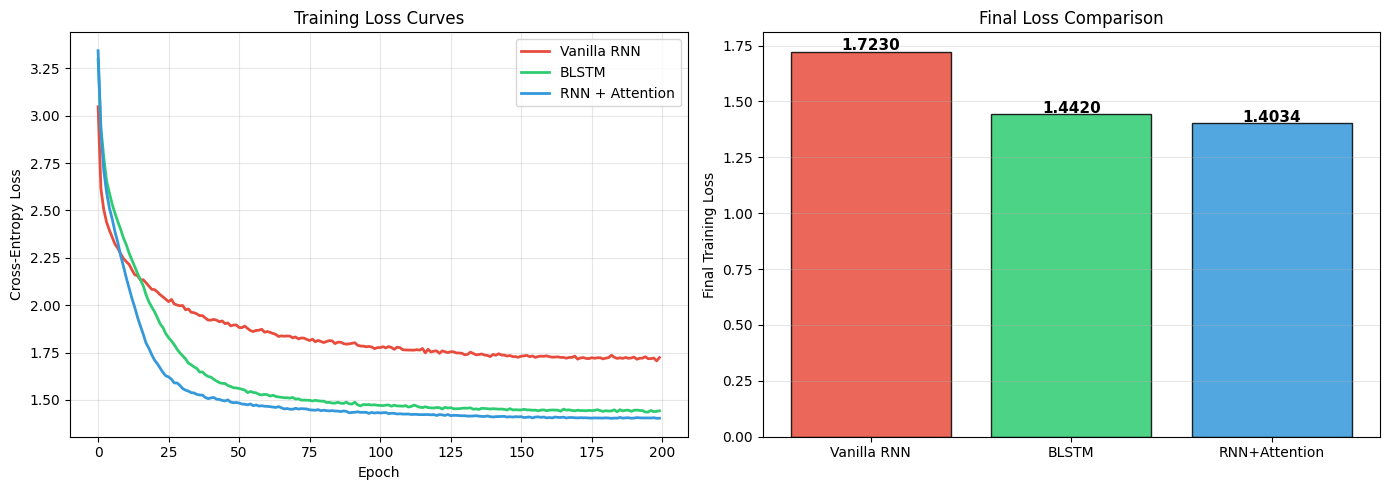

✅ Saved: training_curves.png


In [9]:
# Training loss plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(rnn_losses,   label="Vanilla RNN",     color="#e74c3c", linewidth=2)
ax.plot(blstm_losses, label="BLSTM",           color="#2ecc71", linewidth=2)
ax.plot(attn_losses,  label="RNN + Attention", color="#3498db", linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Loss Curves"); ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
models_list  = ["Vanilla RNN", "BLSTM", "RNN+Attention"]
final_losses = [rnn_losses[-1], blstm_losses[-1], attn_losses[-1]]
colors_list  = ["#e74c3c", "#2ecc71", "#3498db"]
bars = ax2.bar(models_list, final_losses, color=colors_list, alpha=0.85, edgecolor="black")
ax2.set_ylabel("Final Training Loss"); ax2.set_title("Final Loss Comparison")
for bar, val in zip(bars, final_losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: training_curves.png")

In [10]:
# Name generation functions
#
# Single unified generate_name() function handles all three model types.
#
# KEY MECHANISMS:
#   1. One token per forward call — truly autoregressive for all models
#   2. For RNNWithAttention: past_outputs buffer grows at each step,
#      providing keys for attention (identical to training-time computation)
#   3. Hidden state is always detached between steps (no gradient bleed)
#   4. Repetition penalty: divides logit of recently seen tokens
#   5. Quality filter: blocks non-alpha chars, too-short/long names

VALID_CHARS = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ")

def generate_name(model, temperature=0.8, max_len=15, device=None,
                  is_attention=False):
    """
    Autoregressively generate one name, one token at a time.

    Args:
        model        : trained model (VanillaRNN / BidirectionalLSTM / RNNWithAttention)
        temperature  : sampling temperature (lower=conservative, higher=creative)
        max_len      : max characters to generate
        is_attention : True for RNNWithAttention (uses past_outputs buffer)

    Returns: generated name string
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    with torch.no_grad():
        token        = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
        hidden       = None
        past_outputs = None   # growing buffer for attention model
        generated_ids = []
        chars = []

        for step in range(max_len):
            # ── Forward pass ──────────────────────────────────────────────
            if is_attention:
                # Returns (logits, hidden, gru_out)
                logits, hidden, gru_out = model(token, hidden, past_outputs)
                # Append this step's GRU output to past buffer for next step
                past_outputs = gru_out.detach() if past_outputs is None \
                               else torch.cat([past_outputs, gru_out.detach()], dim=1)
            else:
                # Returns (logits, hidden)
                logits, hidden = model(token, hidden)

            # ── Detach hidden state (prevents graph accumulation) ─────────
            if isinstance(hidden, tuple):        # LSTM: (h, c)
                hidden = (hidden[0].detach(), hidden[1].detach())
            elif isinstance(hidden, list):       # Vanilla RNN: list of tensors
                hidden = [h.detach() for h in hidden]
            elif hidden is not None:             # GRU: single tensor
                hidden = hidden.detach()

            # ── Get logits for last timestep ──────────────────────────────
            logit = logits[0, -1, :].clone()     # (vocab_size,)

            # ── Hard-block invalid tokens ──────────────────────────────────
            logit[PAD_IDX] = -1e9
            logit[SOS_IDX] = -1e9
            for idx in range(VOCAB_SIZE):
                ch = idx2char.get(idx, "")
                if ch not in VALID_CHARS and idx != EOS_IDX:
                    logit[idx] = -1e9

            # Don't allow EOS in first 2 steps (avoids 0-1 char names)
            if step < 2:
                logit[EOS_IDX] = -1e9

            # ── Repetition penalty ─────────────────────────────────────────
            # Penalise tokens seen in last 3 steps with increasing severity
            for i, prev in enumerate(reversed(generated_ids[-3:])):
                penalty = 3.0 - i * 0.5           # 3.0, 2.5, 2.0
                logit[prev] = logit[prev] / penalty

            # Break exact bigram loops (e.g. ababab)
            if len(generated_ids) >= 3 and generated_ids[-1] == generated_ids[-3]:
                logit[generated_ids[-1]] = -1e9

            # ── Temperature sampling ───────────────────────────────────────
            probs = F.softmax(logit / temperature, dim=-1)
            if torch.isnan(probs).any() or probs.sum() < 0.1:
                next_tok = logit.argmax().item()  # greedy fallback
            else:
                next_tok = torch.multinomial(probs, 1).item()

            if next_tok == EOS_IDX:
                break

            generated_ids.append(next_tok)
            chars.append(idx2char[next_tok])
            token = torch.tensor([[next_tok]], dtype=torch.long).to(device)

    return "".join(chars)


def is_valid_name(name):
    """
    Quality filter for generated names.
    Enforces: alphabetic, length 3-14, at least 3 distinct chars,
    no run of 3+ identical consecutive chars.
    """
    if not name or not name.isalpha(): return False
    if len(name) < 3 or len(name) > 14: return False
    if len(set(name.lower())) < 3: return False
    if any(name[i] == name[i+1] == name[i+2] for i in range(len(name)-2)): return False
    return True


def generate_names_batch(model, model_type="rnn", n=200, temperature=0.8):
    """Generate n valid names using quality filter."""
    device   = next(model.parameters()).device
    is_attn  = (model_type == "attention")
    names, attempts = [], 0
    while len(names) < n and attempts < n * 8:
        attempts += 1
        raw  = generate_name(model, temperature=temperature, device=device, is_attention=is_attn)
        name = raw.strip().capitalize()
        if is_valid_name(name):
            names.append(name)
    return names


# ── Sanity check ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Sanity check — 10 names per model at temperature 0.8")
print("-"*60)
rnn_check  = [generate_name(rnn_model,   device=device) for _ in range(10)]
blstm_check = [generate_name(blstm_model, device=device) for _ in range(10)]
attn_check  = [generate_name(attn_model,  device=device, is_attention=True) for _ in range(10)]
print(f"Vanilla RNN  : {rnn_check}")
print(f"BLSTM        : {blstm_check}")
print(f"RNN+Attention: {attn_check}")

Sanity check — 10 names per model at temperature 0.8
------------------------------------------------------------
Vanilla RNN  : ['ARshwarya', 'Malina', 'Surya', 'Surebha', 'Latishan', 'Atif', 'Karthika', 'rimanshidevi', 'Gitadikya', 'Kalsinder']
BLSTM        : ['Vijayahari', 'Shivanikant', 'Rashmiraj', 'Inderjit', 'Lekha', 'Mohit', 'Harjothari', 'SusmitapTRhati', 'Gitapoad', 'Rajoviya']
RNN+Attention: ['Hemavbati', 'Pran', 'Dinesh', 'Mitali', 'Suhasinidevi', 'Sahildas', 'Mepani', 'ShivaWi', 'Atul', 'KarunakShram']


In [11]:
# Task-2 — Quantitative Evaluation
#
# Metrics (as required by assignment):
#   Novelty Rate: % of generated names NOT in the training set
#   Diversity   : unique names / total generated names
# Additional metrics:
#   Avg name length, unique count

def evaluate_model(model, model_name, model_type="rnn", n_generate=500, temperature=0.8):
    print(f"\nEvaluating: {model_name}")
    generated = generate_names_batch(model, model_type=model_type,
                                     n=n_generate, temperature=temperature)
    total = len(generated)

    # Novelty: not in training set (case-insensitive)
    train_lower = set(n.lower() for n in all_names)
    novel        = [n for n in generated if n.lower() not in train_lower]
    novelty_rate = len(novel) / total * 100 if total > 0 else 0

    # Diversity: unique / total
    unique_set = set(n.lower() for n in generated)
    diversity  = len(unique_set) / total * 100 if total > 0 else 0

    avg_len = np.mean([len(n) for n in generated]) if generated else 0

    print(f"  Total generated : {total}")
    print(f"  Novelty Rate    : {novelty_rate:.2f}%")
    print(f"  Diversity       : {diversity:.2f}%")
    print(f"  Unique names    : {len(unique_set)}")
    print(f"  Avg name length : {avg_len:.2f}")
    print(f"  Samples         : {generated[:15]}")

    return {
        "model": model_name, "total": total,
        "novelty_rate": novelty_rate, "diversity": diversity,
        "unique_count": len(unique_set), "avg_length": avg_len,
        "generated_names": generated
    }

results_rnn   = evaluate_model(rnn_model,   "Vanilla RNN",     "rnn")
results_blstm = evaluate_model(blstm_model, "BLSTM",           "blstm")
results_attn  = evaluate_model(attn_model,  "RNN + Attention", "attention")

all_results = [results_rnn, results_blstm, results_attn]

# Save generated names to text files
for res in all_results:
    fname = res["model"].replace(" ", "_").replace("+", "plus") + "_generated.txt"
    with open(fname, "w") as f:
        for name in res["generated_names"]: f.write(name + "\n")
    print(f"Saved {len(res['generated_names'])} names → {fname}")


Evaluating: Vanilla RNN
  Total generated : 500
  Novelty Rate    : 63.40%
  Diversity       : 87.80%
  Unique names    : 439
  Avg name length : 7.84
  Samples         : ['Malini', 'Zara', 'Aman', 'Harishram', 'Soumyadip', 'Ayush', 'Raj', 'Souudas', 'Sugany', 'Rajeshwaridevo', 'Divyadev', 'Latiwashram', 'Naveon', 'Vennilam', 'Saurabh']

Evaluating: BLSTM
  Total generated : 500
  Novelty Rate    : 48.00%
  Diversity       : 88.80%
  Unique names    : 444
  Avg name length : 8.45
  Samples         : ['Ravikumar', 'Priyanshi', 'Gitaporvi', 'Lubnaprabhe', 'Raghsanakumar', 'Kamyal', 'Maohurimawjz', 'Amanprevt', 'Ramya', 'Vaibhav', 'Prathapdevi', 'Sharmistha', 'Subhashrez', 'Gurdehprabhu', 'Karvinder']

Evaluating: RNN + Attention
  Total generated : 500
  Novelty Rate    : 43.80%
  Diversity       : 84.40%
  Unique names    : 422
  Avg name length : 8.39
  Samples         : ['Prachi', 'Gitamohsin', 'Karhil', 'Sidwarup', 'Srilakshmi', 'Malintamhari', 'Harijayalritya', 'Sekhil', 'Gitapotai

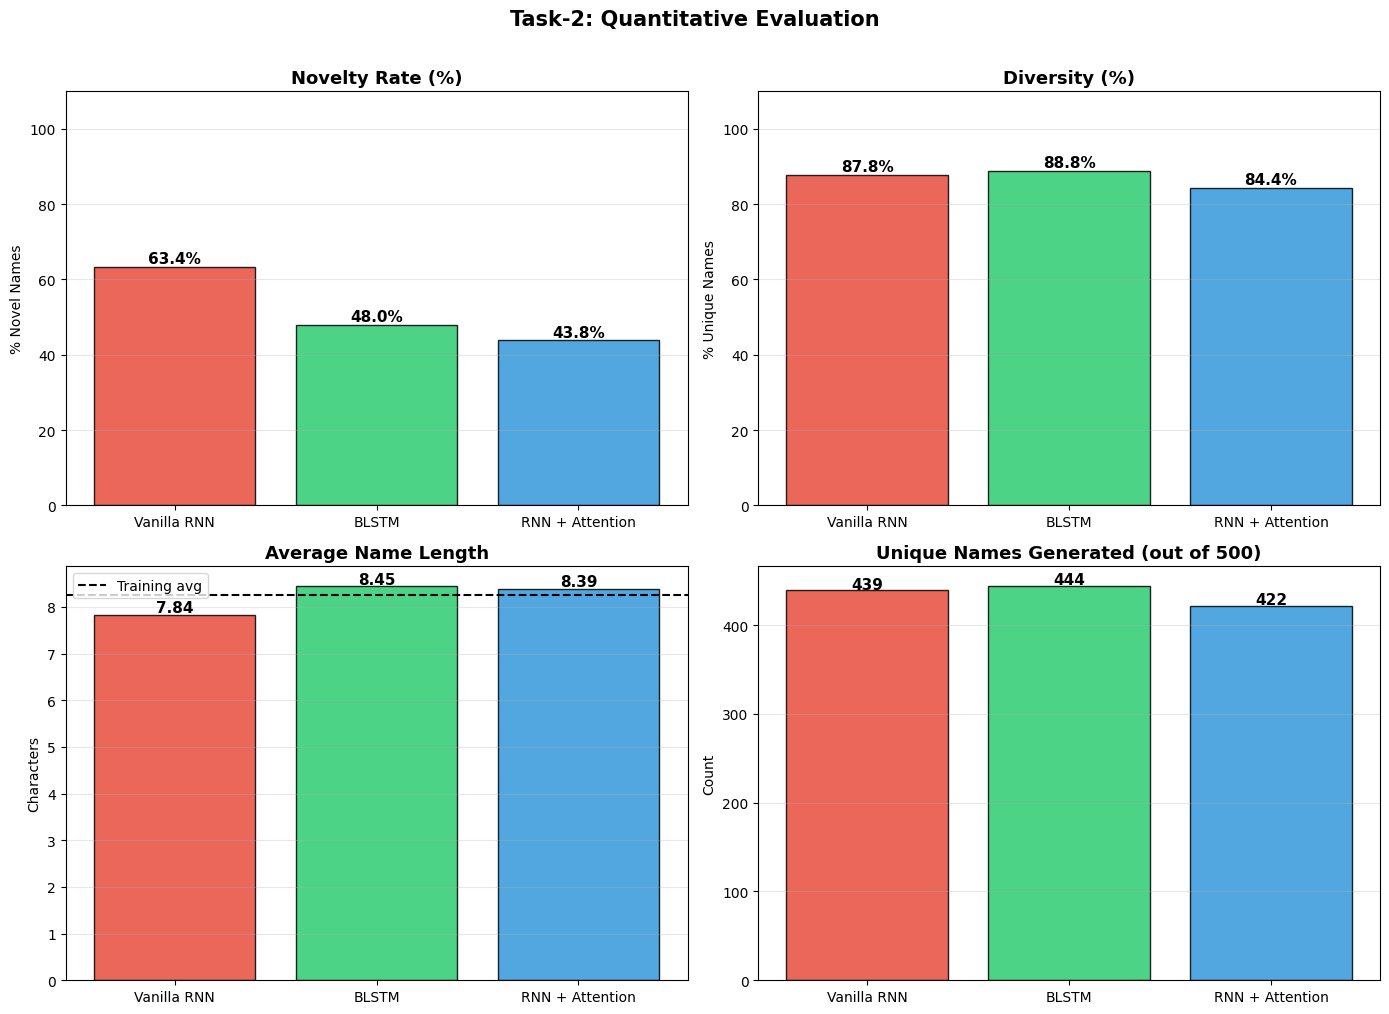

✅ Saved: evaluation_metrics.png


In [12]:
# Evaluation metric plots (Task-2 visualisation)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
model_names_list = [r["model"] for r in all_results]
colors_list = ["#e74c3c", "#2ecc71", "#3498db"]

# Novelty
ax = axes[0, 0]
novelty = [r["novelty_rate"] for r in all_results]
bars = ax.bar(model_names_list, novelty, color=colors_list, alpha=0.85, edgecolor="black")
ax.set_title("Novelty Rate (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("% Novel Names"); ax.set_ylim(0, 110)
for bar, val in zip(bars, novelty):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# Diversity
ax = axes[0, 1]
diversity = [r["diversity"] for r in all_results]
bars = ax.bar(model_names_list, diversity, color=colors_list, alpha=0.85, edgecolor="black")
ax.set_title("Diversity (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("% Unique Names"); ax.set_ylim(0, 110)
for bar, val in zip(bars, diversity):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# Avg length
ax = axes[1, 0]
avg_lens = [r["avg_length"] for r in all_results]
bars = ax.bar(model_names_list, avg_lens, color=colors_list, alpha=0.85, edgecolor="black")
ax.set_title("Average Name Length", fontsize=13, fontweight="bold")
ax.set_ylabel("Characters")
ax.axhline(np.mean([len(n) for n in all_names]), color="black",
           linestyle="--", linewidth=1.5, label="Training avg")
ax.legend()
for bar, val in zip(bars, avg_lens):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# Unique count
ax = axes[1, 1]
unique_counts = [r["unique_count"] for r in all_results]
bars = ax.bar(model_names_list, unique_counts, color=colors_list, alpha=0.85, edgecolor="black")
ax.set_title("Unique Names Generated (out of 500)", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
for bar, val in zip(bars, unique_counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f"{val}", ha="center", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Task-2: Quantitative Evaluation", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: evaluation_metrics.png")


Qualitative Analysis: Vanilla RNN

  Temperature Low (0.5) — Conservative:
  → ['Suraj', 'Manikand', 'Arunav', 'Sahildas', 'Devarnsh', 'Rajeshwari', 'Kalaidevi', 'Sharmistha', 'Soundaraj', 'Rajgurwinder', 'Sahil', 'Mala', 'Saroja', 'Devarna', 'Shrisonam']

  Temperature Medium (0.8) — Balanced:
  → ['Kritha', 'Sarojat', 'Karthika', 'Ishita', 'Amalktsal', 'Thrilakshmi', 'Anirudf', 'Umaarveen', 'Rajsmita', 'Sajshika', 'Shriadhinath', 'Susanyalat', 'Jagjewtumay', 'Karundef', 'Vikramdas']

  Temperature High (1.2) — Creative:
  → ['Dhruv', 'Pruchgla', 'Krwaenaksrila', 'Junamritrajs', 'Gusurabh', 'Dheshkant', 'Vinaysram', 'Simrant', 'Kamri', 'Harsimref', 'Murgsarmashri', 'Rohan', 'Kaloujwarv', 'Mithuddpak', 'Saeshi']

Qualitative Analysis: BLSTM

  Temperature Low (0.5) — Conservative:
  → ['Mandeepkumar', 'Madhurimakumar', 'Shrisalma', 'Anirudhpal', 'Anirudhpal', 'Ajithdas', 'Narmada', 'Anildas', 'Ashwin', 'Arunwati', 'Salmin', 'Shrisalma', 'Sanjukta', 'Shridev', 'Samrecna']

  Temperatur

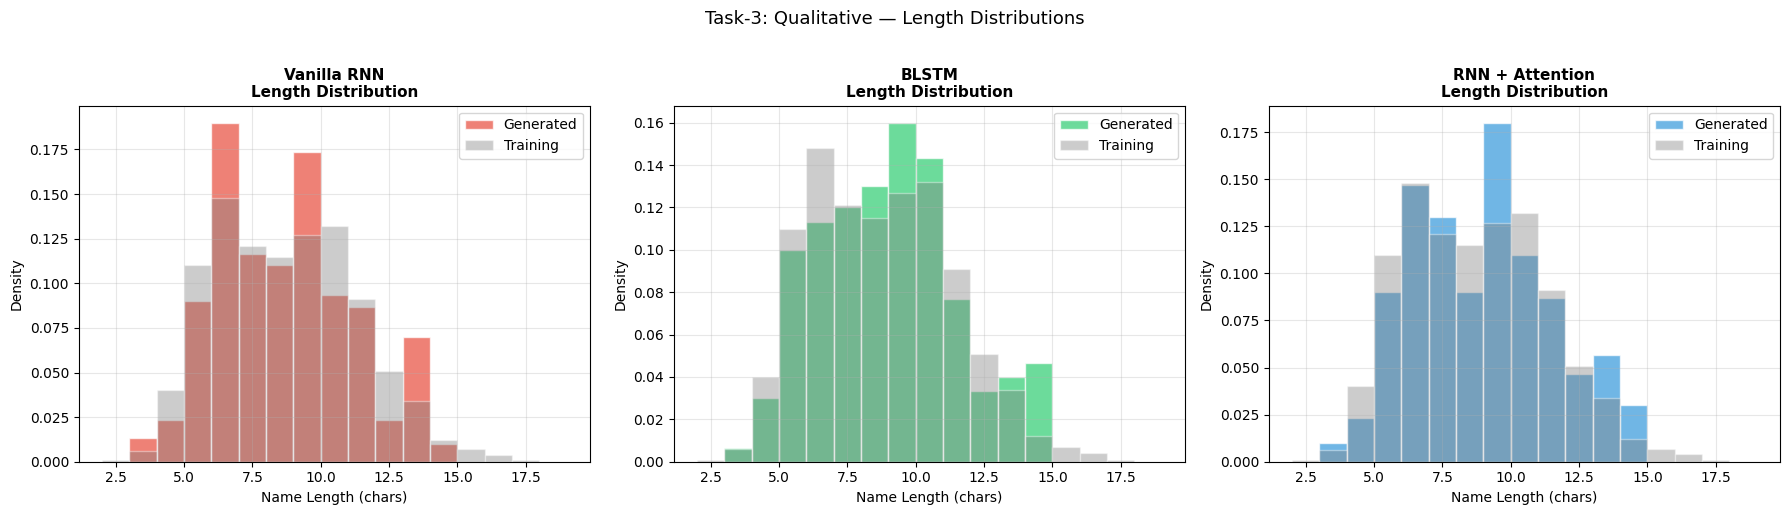

✅ Saved: length_distribution.png


In [13]:
# Task-3 — Qualitative Analysis
# Generate names at three temperatures and analyse length distributions

def qualitative_analysis(model, model_name, model_type="rnn", n_samples=100):
    """
    Generate names at low/medium/high temperature to illustrate
    the effect of sampling temperature on name creativity vs realism.
    """
    print(f"\n{'='*60}")
    print(f"Qualitative Analysis: {model_name}")
    print("="*60)
    temps       = [0.5, 0.8, 1.2]
    temp_labels = ["Low (0.5) — Conservative",
                   "Medium (0.8) — Balanced",
                   "High (1.2) — Creative"]
    temp_samples = {}
    for temp, label in zip(temps, temp_labels):
        names = generate_names_batch(model, model_type=model_type,
                                     n=n_samples, temperature=temp)
        temp_samples[temp] = names
        print(f"\n  Temperature {label}:")
        print(f"  → {names[:15]}")
    return temp_samples

rnn_qualitative   = qualitative_analysis(rnn_model,   "Vanilla RNN",     "rnn")
blstm_qualitative = qualitative_analysis(blstm_model, "BLSTM",           "blstm")
attn_qualitative  = qualitative_analysis(attn_model,  "RNN + Attention", "attention")

# ── Length distribution plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_info = [
    ("Vanilla RNN",     rnn_qualitative,   "#e74c3c"),
    ("BLSTM",           blstm_qualitative, "#2ecc71"),
    ("RNN + Attention", attn_qualitative,  "#3498db"),
]
for ax, (mname, qual_data, color) in zip(axes, model_info):
    all_gen = []
    for names in qual_data.values(): all_gen.extend(names)
    lengths       = [len(n) for n in all_gen]
    train_lengths = [len(n) for n in all_names]
    ax.hist(lengths,       bins=range(2, 20), alpha=0.7, color=color,
            label="Generated", density=True, edgecolor="white")
    ax.hist(train_lengths, bins=range(2, 20), alpha=0.4, color="gray",
            label="Training",  density=True, edgecolor="white")
    ax.set_title(f"{mname}\nLength Distribution", fontsize=11, fontweight="bold")
    ax.set_xlabel("Name Length (chars)"); ax.set_ylabel("Density")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Task-3: Qualitative — Length Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: length_distribution.png")

In [14]:
# Summary table + save report_data.json

param_counts = {
    "Vanilla RNN":     rnn_model.count_parameters(),
    "BLSTM":           blstm_model.count_parameters(),
    "RNN + Attention": attn_model.count_parameters()
}
loss_map = {
    "Vanilla RNN": rnn_losses[-1],
    "BLSTM":       blstm_losses[-1],
    "RNN + Attention": attn_losses[-1]
}

print("="*80)
print(f"{'FINAL SUMMARY TABLE':^80}")
print("="*80)
print(f"{'Model':<22} {'Params':>10} {'Loss':>10} {'Novelty%':>10} {'Diversity%':>12} {'AvgLen':>8}")
print("-"*80)
for res in all_results:
    mn = res['model']
    print(f"{mn:<22} {param_counts[mn]:>10,} {loss_map[mn]:>10.4f} "
          f"{res['novelty_rate']:>10.2f} {res['diversity']:>12.2f} {res['avg_length']:>8.2f}")
print("="*80)

report_data = {
    "vocab_size": VOCAB_SIZE,
    "num_training_names": len(all_names),
    "hyperparameters": {
        "embed_dim": 64, "hidden_size": 256, "num_layers": 2,
        "dropout": 0.3, "attention_dim": 128,
        "learning_rate": 0.002, "batch_size": 64
    },
    "model_params": param_counts,
    "final_losses": loss_map,
    "evaluation": {
        r["model"]: {
            "novelty_rate": r["novelty_rate"], "diversity": r["diversity"],
            "unique_count": r["unique_count"], "avg_length": r["avg_length"]
        } for r in all_results
    },
    "sample_names": {
        r["model"]: r["generated_names"][:30] for r in all_results
    }
}
with open("report_data.json", "w") as f:
    json.dump(report_data, f, indent=2)

print("\n report_data.json saved")

                              FINAL SUMMARY TABLE                               
Model                      Params       Loss   Novelty%   Diversity%   AvgLen
--------------------------------------------------------------------------------
Vanilla RNN               230,517     1.7230      63.40        87.80     7.84
BLSTM                   3,372,149     1.4420      48.00        88.80     8.45
RNN + Attention           856,053     1.4034      43.80        84.40     8.39

✅ report_data.json saved
